Pietro sent some new list of type 2 for adding them to our labelled dataset. If adding them improves model performance for type 2 will justify the need for more data samples for under-represented data samples thus justifying the need for GAN to generate synthetic data images. 

First I gotta make a script to take specific timestamps from unlabelled dataset and add them to labelled dataset. I will try to find these timestamps for type 2 from the unlabelled dataset because, if they will be present in the unlaballed dataset (filtered and unfiltered), the model will be able to perform well on them since it already saw them in the labelled dataset. The plan is do a final test on the unfiltered dataset samples as the final test for the model. Thus we need to ensure that the image is no longer present is the filtered unlabelled dataset atleast since the pretrain model pretrains on it. 

So first step is to find these specific type 2 timestamps from pietros list and append them to labelled dataset while simultanously making sure to remove them from the unlabelled filtered dataset. 

TIMESTAMPS_TO_MOVE = [
     "2022-08-03_17:15:00","867649_2022-08-05_07:00:00", "872004_2022=09-23_14:00:00", "873300_2022-10-11_08:45:00", "873300_2022-10-11_11:00:00",
    "873300_2022-10-11_11:15:00", "876498_2022-11-19_12:56:00", "877600_2022-12-14_08:26:00", "880330_2023_01_13_10:11:00", "880330_2023_01_13_10:26:00", 
    "880334_2023-01-14_12:41:00", "880334_2023-01-14_12:56:00", "881218_2023=02-09_07:26:00", "888140_2023-05-04_08:41:00", "888144_2023-05-05_07:11:00", 
    "888144_2023-05-05_07:41:00", "888168_2023-05-11_08:56:00", "888168_2023-05-11_09:11:00", "888464_2023-05-17_15:15:00", "888484_2023-05-22_13:41:00", 
    "2021311_2023-07-07_09:58:00", "2021311_2023-07-07_10:13:00", "2021338_2023-07-10_11:45:00", "2022421_2023-07-15_10:20:00", "2022421_2023-07-15_16:35:00",
    "2022439_2023-07-19_17:38:01.000000", "2022445_2023-07-19_17:24:00", "2022572_2023-07-24_17:30:00", "2022572_2023-07-24_17:45:00", "2022572_2023-07-24_18:00:00",
    "2022596_2023-07-28_15:50:00", "2022596_2023-07-28_16:05:00", "2022602_2023-07-29_07:21:00", "2022644_2023-08-05_07:00:00", "2024373_2023-08-17_12:32:00",
    "2024373_2023-08-17_12:47:00", "2024391_2023-08-20_06:22:00", "2025187_2023-09-17_16:07:00", "2025205_2023-09-20_14:27:00", "2025229_2023-09-24_15:04:00",
    "2028255_2023_11-02_12:27:00", "2028693_2024-01-14_11:40:00", "2028783_2024-01-29_10:25:00", "2028807_2024-02-02_11:01:00", "2028843_2024-02-08_11:46:00", 
    "2028897_2024-02-17_13:24:00","2028897_2024-02-17_13:39:00","2028897_2024-02-17_13:54:00", "2028963_2024-02-28_08:55:00", "2028963_2024-02-28_09:10:00", 
    "2029029_2024-03-10_12:12:00", "2029029_2024-03-10_12:27:00", "2029299_2024-04-24_14:14:00", "2029299_2024-04-24_14:29:00", "2040132_2024-05-14_12:56:00",
    "2040132_2024-05-14_17:11:00", "2040132_2024-05-14_17:26:00", "2040132_2024-05-14_17:41:00", "2040281_2024-05-27_07:12:00", "2040281_2024-05-27_07:27:00",
    "2040812_2024-05-29_14:20:00", "2040812_2024-05-29_14:50:00", "2041027_2024-06-17_10:34:00", "2041027_2024-06-17_10:49:00", "2042220_2024-07-04_14:26:00",
    "2042220_2024-07-04_14:41:00", "2042274_2024-07-13_12:34:00", "2042274_2024-07-13_12:49:00", "2042220_2024-07-04_16:41:00", "2042956_2024-07-16_13:30:00",
    "2042956_2024-07-16_13:45:00", "2042328_2024-07-22_09:28:00", "2042340_2024-07-24_07:46:00", "2042340_2024-07-24_17:31:00", "2043545_2024-08-01_07:11:00", 
    "2043850_2024-08-09_12:07:00", "2044342_2024-08-14_07:05:00"

In [29]:

# =====================
# 🔧 CONFIG — EDIT ME
# =====================
UNLAB_H5 = "../../../project/lofarsw/Data/Dynspec/full_data/dset_2025.h5"
LAB_H5   = "../../../project/lofarsw/Data/Dynspec/labelled_dataset.h5"

# Example formats accepted for queries:
#   "2022-05-20T06:30:00"
#   "2022-05-20 06:30:00"
#   "2022-05-20_06:30:00.000000"
#   "861374_2022-05-20_06:30:00.000000"   # id-prefixed form (will be normalized)
TIMESTAMPS_TO_MOVE = [
     "2022-08-03_17:15:00","867649_2022-08-05_07:00:00", "872004_2022=09-23_14:00:00", "873300_2022-10-11_08:45:00", "873300_2022-10-11_11:00:00",
    "873300_2022-10-11_11:15:00", "876498_2022-11-19_12:56:00", "877600_2022-12-14_08:26:00", "880330_2023_01_13_10:11:00", "880330_2023_01_13_10:26:00", 
    "880334_2023-01-14_12:41:00", "880334_2023-01-14_12:56:00", "881218_2023=02-09_07:26:00", "888140_2023-05-04_08:41:00", "888144_2023-05-05_07:11:00", 
    "888144_2023-05-05_07:41:00", "888168_2023-05-11_08:56:00", "888168_2023-05-11_09:11:00", "888464_2023-05-17_15:15:00", "888484_2023-05-22_13:41:00", 
    "2021311_2023-07-07_09:58:00", "2021311_2023-07-07_10:13:00", "2021338_2023-07-10_11:45:00", "2022421_2023-07-15_10:20:00", "2022421_2023-07-15_16:35:00",
    "2022439_2023-07-19_17:38:01.000000", "2022445_2023-07-19_17:24:00", "2022572_2023-07-24_17:30:00", "2022572_2023-07-24_17:45:00", "2022572_2023-07-24_18:00:00",
    "2022596_2023-07-28_15:50:00", "2022596_2023-07-28_16:05:00", "2022602_2023-07-29_07:21:00", "2022644_2023-08-05_07:00:00", "2024373_2023-08-17_12:32:00",
    "2024373_2023-08-17_12:47:00", "2024391_2023-08-20_06:22:00", "2025187_2023-09-17_16:07:00", "2025205_2023-09-20_14:27:00", "2025229_2023-09-24_15:04:00",
    "2028255_2023_11-02_12:27:00", "2028693_2024-01-14_11:40:00", "2028783_2024-01-29_10:25:00", "2028807_2024-02-02_11:01:00", "2028843_2024-02-08_11:46:00", 
    "2028897_2024-02-17_13:24:00","2028897_2024-02-17_13:39:00","2028897_2024-02-17_13:54:00", "2028963_2024-02-28_08:55:00", "2028963_2024-02-28_09:10:00", 
    "2029029_2024-03-10_12:12:00", "2029029_2024-03-10_12:27:00", "2029299_2024-04-24_14:14:00", "2029299_2024-04-24_14:29:00", "2040132_2024-05-14_12:56:00",
    "2040132_2024-05-14_17:11:00", "2040132_2024-05-14_17:26:00", "2040132_2024-05-14_17:41:00", "2040281_2024-05-27_07:12:00", "2040281_2024-05-27_07:27:00",
    "2040812_2024-05-29_14:20:00", "2040812_2024-05-29_14:50:00", "2041027_2024-06-17_10:34:00", "2041027_2024-06-17_10:49:00", "2042220_2024-07-04_14:26:00",
    "2042220_2024-07-04_14:41:00", "2042274_2024-07-13_12:34:00", "2042274_2024-07-13_12:49:00", "2042220_2024-07-04_16:41:00", "2042956_2024-07-16_13:30:00",
    "2042956_2024-07-16_13:45:00", "2042328_2024-07-22_09:28:00", "2042340_2024-07-24_07:46:00", "2042340_2024-07-24_17:31:00", "2043545_2024-08-01_07:11:00", 
    "2043850_2024-08-09_12:07:00", "2044342_2024-08-14_07:05:00"
    
    
]

# Label assigned in LABELLED for appended rows
LABEL_VALUE = 2

# Preview only (no writes) when True
DRY_RUN = True

# Create timestamped .bak files before modifying anything
MAKE_BACKUPS = True


In [30]:

import os, shutil, time, re
from pathlib import Path
import numpy as np
import h5py

def ts_now():
    return time.strftime("%Y%m%d_%H%M%S")

def backup_file(path):
    p = Path(path)
    bak = p.with_suffix(p.suffix + f".bak_{ts_now()}")
    shutil.copy2(p, bak)
    return str(bak)

def list_all_datasets(h5obj):
    out = []
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            out.append(("/" + name, obj))
    h5obj.visititems(visitor)
    return out

def detect_num_samples(h5):
    candidates = []
    for path, dset in list_all_datasets(h5):
        shp = dset.shape
        if len(shp) >= 1:
            candidates.append((path, shp))
    pref = sorted(candidates, key=lambda x: (0 if len(x[1])>=2 else 1, x[1][0]))
    if pref:
        return pref[0][1][0]
    raise RuntimeError("Could not detect N (first dimension).")

def is_per_sample(dset, N):
    return (len(dset.shape)>=1 and dset.shape[0]==N)

def copy_attrs(src_obj, dst_obj):
    for k, v in src_obj.attrs.items():
        dst_obj.attrs[k] = v

def create_like(dst_group, name, shape, dtype, src_dset=None, compression=None, chunks=None, maxshape=None):
    if src_dset is not None:
        compression = src_dset.compression
        chunks = src_dset.chunks
        maxshape = None
    return dst_group.create_dataset(name, shape=shape, dtype=dtype, compression=compression, chunks=chunks, maxshape=maxshape)

# ---------- Timestamp normalization tailored to your UNLABELLED schema ----------

def _decode_obj(x):
    if isinstance(x, bytes):
        try:
            return x.decode("utf-8", errors="ignore")
        except Exception:
            return str(x)
    return str(x)

def _strip_id_prefix(s):
    m = re.match(r"^(\d+)[_-](.*)$", s)
    return m.group(2) if m else s

def _drop_microseconds(s):
    return re.sub(r"(\d{2}:\d{2}:\d{2})(\.\d+)", r"\1", s)

def normalize_unlabelled_ts(s):
    s = _decode_obj(s).strip()
    if s.startswith("b'") and s.endswith("'"):
        s = s[2:-1]
    s = _strip_id_prefix(s)
    s = s.replace(" ", "T")
    parts = s.split("_")
    if len(parts) >= 3:
        date = parts[-2]
        timep = parts[-1]
        s = f"{date}T{timep}"
    s = _drop_microseconds(s)
    s = s.rstrip("Z")
    s = re.sub(r"(\+|\-)\d{2}:?\d{2}$", "", s)
    s = s.replace(" ", "T")
    return s

def normalize_query_ts(s):
    s = _decode_obj(s).strip()
    if s.startswith("b'") and s.endswith("'"):
        s = s[2:-1]
    s = _strip_id_prefix(s)
    s = s.replace(" ", "T")
    parts = s.split("_")
    if len(parts) >= 3:
        date = parts[-2]
        timep = parts[-1]
        s = f"{date}T{timep}"
    s = _drop_microseconds(s)
    s = s.rstrip("Z")
    s = re.sub(r"(\+|\-)\d{2}:?\d{2}$", "", s)
    s = s.replace(" ", "T")
    return s

def guess_time_dataset(h5, N):
    if "timestamps" in h5 and isinstance(h5["timestamps"], h5py.Dataset) and h5["timestamps"].shape[0]==N:
        return {"kind":"point", "name":"timestamps"}
    if "time_range" in h5 and isinstance(h5["time_range"], h5py.Dataset) and h5["time_range"].shape[0]==N and h5["time_range"].shape[1]==2:
        return {"kind":"range", "name":"time_range"}
    for path, d in list_all_datasets(h5):
        if is_per_sample(d, N):
            base = Path(path).name.lower()
            if base in ("timestamps","timestamp","time"):
                return {"kind":"point", "name": path}
            if base in ("time_range","timerange","timespan"):
                if len(d.shape)==2 and d.shape[1]==2:
                    return {"kind":"range", "name": path}
    return None

def discover_label_dataset(h5):
    for path, d in list_all_datasets(h5):
        if len(d.shape)==1:
            base = Path(path).name.lower()
            if base in ("labels","label"):
                if d.dtype.kind in ("i","u"):
                    return (path, "int")
                else:
                    return (path, "str")
            if base in ("labels_str","label_str","label_strings","labels_strings"):
                return (path, "str")
    return None

def match_indices_point_strings(h5, time_info, queries):
    dset = h5[time_info["name"]]
    N = dset.shape[0]
    raw = dset[:]
    arr_norm = np.array([normalize_unlabelled_ts(raw[i]) for i in range(N)], dtype=object)
    qnorm = [normalize_query_ts(q) for q in queries]

    idxs = []
    found = set()
    val2idx = {}
    for i, v in enumerate(arr_norm):
        val2idx.setdefault(v, []).append(i)
    for q in qnorm:
        if q in val2idx:
            for i in val2idx[q]:
                if i not in found:
                    found.add(i); idxs.append(i)
    missing = [q for q in qnorm if q not in val2idx]
    if missing:
        arr_u = np.array(arr_norm, dtype="U")
        for q in missing:
            hits = np.where(np.char.find(arr_u, q) >= 0)[0]
            for i in hits:
                if i not in found:
                    found.add(i); idxs.append(i)
    idxs = np.array(sorted(idxs), dtype=np.int64)
    print(f"[timestamps] matched {len(idxs)} indices for {len(queries)} queries.")
    for i in idxs[:5]:
        print("  match idx", i, "stored=", arr_norm[i])
    return idxs

def match_indices_range(h5, time_info, queries):
    dset = h5[time_info["name"]]
    N = dset.shape[0]
    rng = dset[:]
    starts = np.array([normalize_unlabelled_ts(rng[i,0]) for i in range(N)], dtype=object)
    ends   = np.array([normalize_unlabelled_ts(rng[i,1]) for i in range(N)], dtype=object)

    def to_dt64(arr):
        out = []
        for s in arr:
            try: out.append(np.datetime64(s))
            except Exception: out.append(None)
        return out

    s_dt = to_dt64(starts); e_dt = to_dt64(ends)
    idxs = set()
    qnorm = [normalize_query_ts(q) for q in queries]
    for q in qnorm:
        try: qdt = np.datetime64(q)
        except Exception: qdt = None
        if qdt is not None and any(x is not None for x in s_dt[:10]):
            for i, (a,b) in enumerate(zip(s_dt, e_dt)):
                if a is None or b is None: continue
                if a <= qdt <= b: idxs.add(i)
        else:
            for i, (a,b) in enumerate(zip(starts, ends)):
                if a <= q <= b: idxs.add(i)
    idxs = np.array(sorted(list(idxs)), dtype=np.int64)
    print(f"[time_range] matched {len(idxs)} indices for {len(queries)} queries.")
    for i in idxs[:5]:
        print("  match idx", i, "range=", starts[i], "→", ends[i])
    return idxs

def rebuild_unlabelled_without(h5u_path, idxs_to_remove, dry_run=False):
    if dry_run:
        print("[DRY-RUN] Skipping rebuild of UNLABELLED."); return
    tmp_path = str(Path(h5u_path).with_suffix(".tmp.h5"))
    with h5py.File(h5u_path, "r") as src, h5py.File(tmp_path, "w") as dst:
        copy_attrs(src, dst)
        N = detect_num_samples(src)
        mask = np.ones(N, dtype=bool); mask[idxs_to_remove] = False
        def copier(name, obj):
            if isinstance(obj, h5py.Group):
                dst.require_group(name); copy_attrs(obj, dst[name])
            elif isinstance(obj, h5py.Dataset):
                if is_per_sample(obj, N):
                    data = obj[mask, ...]
                    d = create_like(dst, name, data.shape, obj.dtype, src_dset=obj); d[...] = data; copy_attrs(obj, d)
                else:
                    d = create_like(dst, name, obj.shape, obj.dtype, src_dset=obj); d[...] = obj[...]; copy_attrs(obj, d)
        src.visititems(lambda n,o: copier(n,o))
    bak = h5u_path + f".old_{ts_now()}"
    os.replace(h5u_path, bak); os.replace(tmp_path, h5u_path)
    print(f"Rebuilt UNLABELLED without {len(idxs_to_remove)} rows. Old file moved to: {bak}")

def append_rows_to_labelled(h5l_path, rows_dict, label_value=2, dry_run=False):
    K = None
    for v in rows_dict.values():
        if isinstance(v, np.ndarray):
            K = v.shape[0]; break
    if not K: print("No rows to append."); return
    if dry_run: print(f"[DRY-RUN] Would append {K} rows to LABELLED with label={label_value}."); return

    tmp_path = str(Path(h5l_path).with_suffix(".tmp.h5"))
    if not Path(h5l_path).exists():
        with h5py.File(tmp_path, "w") as dst:
            for name, arr in rows_dict.items():
                d = create_like(dst, name, arr.shape, arr.dtype, src_dset=None); d[...] = arr
            lab = dst.create_dataset("labels", shape=(K,), dtype=np.int64); lab[...] = label_value
        os.replace(tmp_path, h5l_path); print(f"Created new LABELLED with {K} rows."); return

    with h5py.File(h5l_path, "r") as src, h5py.File(tmp_path, "w") as dst:
        copy_attrs(src, dst)
        try: M = detect_num_samples(src)
        except RuntimeError: M = 0
        lab_info = discover_label_dataset(src)

        def first_pass(name, obj):
            if isinstance(obj, h5py.Group):
                dst.require_group(name); copy_attrs(obj, dst[name])
        src.visititems(first_pass)

        def copy_or_concat(name, obj):
            if isinstance(obj, h5py.Dataset):
                if M>0 and is_per_sample(obj, M):
                    base = obj[...]; add = rows_dict.get("/"+name, None)
                    concat = base if add is None else np.concatenate([base, add], axis=0)
                    d = create_like(dst, name, concat.shape, obj.dtype, src_dset=obj); d[...] = concat; copy_attrs(obj, d)
                else:
                    d = create_like(dst, name, obj.shape, obj.dtype, src_dset=obj); d[...] = obj[...]; copy_attrs(obj, d)
        src.visititems(copy_or_concat)

        written = set("/"+p for p, _ in list_all_datasets(dst))
        for name, arr in rows_dict.items():
            if name not in written:
                parts = name.strip("/").split("/")
                if len(parts)>1: dst.require_group("/".join(parts[:-1]))
                d = create_like(dst, name.strip("/"), arr.shape, arr.dtype, src_dset=None); d[...] = arr

        if lab_info is not None:
            lname, lkind = lab_info
            if lkind == "int":
                old = src[lname][...]; add = np.full((K,), int(label_value), dtype=old.dtype)
            else:
                old = np.array(src[lname][...]).astype(str); add = np.array([str(label_value)]*K, dtype=old.dtype)
            newlabs = np.concatenate([old, add], axis=0)
            if lname in dst: del dst[lname]
            d = create_like(dst, lname.strip("/"), newlabs.shape, newlabs.dtype, src_dset=None); d[...] = newlabs
        else:
            lab = dst.create_dataset("labels", shape=(M+K,), dtype=np.int64); lab[:M] = -1; lab[M:] = label_value

    bak = h5l_path + f".old_{ts_now()}"
    os.replace(h5l_path, bak); os.replace(tmp_path, h5l_path)
    print(f"Appended {K} rows to LABELLED (old file moved to: {bak}).")


In [31]:

# =====================
# 🔎 Inspect & Match
# =====================
from pathlib import Path
assert Path(UNLAB_H5).exists(), f"UNLABELLED not found: {UNLAB_H5}"
with h5py.File(UNLAB_H5, "r") as hu:
    N = detect_num_samples(hu)
    ti = guess_time_dataset(hu, N)
    print(f"UNLABELLED N={N}")
    print("Detected time dataset:", ti)
    if ti is None:
        raise RuntimeError("No time dataset found. Expected 'timestamps' or 'time_range'.")
    if ti["kind"] == "point":
        IDX_CACHE = match_indices_point_strings(hu, ti, TIMESTAMPS_TO_MOVE)
    else:
        IDX_CACHE = match_indices_range(hu, ti, TIMESTAMPS_TO_MOVE)
N_CACHE = int(N)
TIME_INFO_CACHE = ti
print("Indices to move:", IDX_CACHE.tolist())


UNLABELLED N=49601
Detected time dataset: {'kind': 'point', 'name': 'timestamps'}
[timestamps] matched 71 indices for 77 queries.
  match idx 2261 stored= 2022-08-03_17:15:00
  match idx 2957 stored= 2022-11-19_12:56:00
  match idx 3404 stored= 2022-08-05_07:00:00
  match idx 4345 stored= 2022-10-11_11:00:00
  match idx 4354 stored= 2022-10-11_08:45:00
Indices to move: [2261, 2957, 3404, 4345, 4354, 4356, 11081, 11092, 11366, 12542, 12585, 12623, 13146, 13152, 13423, 13603, 14546, 14564, 14687, 14822, 14859, 15638, 15939, 15940, 15968, 16352, 16393, 16433, 17156, 19596, 19879, 20234, 20359, 20388, 20656, 29937, 31771, 32115, 32370, 32372, 32859, 32860, 32871, 33965, 35100, 35101, 38675, 38703, 40676, 40682, 40691, 40700, 41980, 41985, 42251, 42252, 44507, 44514, 45280, 45289, 45597, 45620, 45632, 45652, 45657, 46180, 46672, 46685, 48050, 48719, 49159]


In [32]:

# Preview per-sample datasets and shape deltas
with h5py.File(UNLAB_H5, "r") as hu:
    print("\nPer-sample datasets to slice:")
    for path, dset in list_all_datasets(hu):
        if is_per_sample(dset, N_CACHE):
            print(f"  {path:28s} -> {tuple(dset.shape)} {dset.dtype}")
if IDX_CACHE.size == 0:
    print("\n⚠️ No matches found. Check your TIMESTAMPS_TO_MOVE format.")



Per-sample datasets to slice:
  /data                        -> (49601, 500, 800) float32
  /freq_range                  -> (49601, 2) float64
  /time_range                  -> (49601, 2) float64
  /timestamps                  -> (49601,) object


In [33]:

# Backups (optional)
if not DRY_RUN and MAKE_BACKUPS:
    if Path(UNLAB_H5).exists():
        b1 = backup_file(UNLAB_H5); print("Backed up UNLABELLED ->", b1)
    if Path(LAB_H5).exists():
        b2 = backup_file(LAB_H5);   print("Backed up LABELLED   ->", b2)


Backed up UNLABELLED -> ../../../project/lofarsw/Data/Dynspec/full_data/dset_2025.h5.bak_20251104_130423
Backed up LABELLED   -> ../../../project/lofarsw/Data/Dynspec/labelled_dataset.h5.bak_20251104_131426


In [34]:

# Build rows to append
rows = {}
K = int(IDX_CACHE.size)
if K == 0:
    print("Nothing to move.")
else:
    with h5py.File(UNLAB_H5, "r") as hu:
        for path, dset in list_all_datasets(hu):
            if is_per_sample(dset, N_CACHE):
                rows[path] = dset[IDX_CACHE, ...]
    print(f"Prepared {K} rows from UNLABELLED to append to LABELLED.")


Prepared 71 rows from UNLABELLED to append to LABELLED.


In [ ]:

# Remove from unlabelled
if K>0:
    rebuild_unlabelled_without(UNLAB_H5, IDX_CACHE, dry_run=DRY_RUN)


In [ ]:

# Summary
print("Done.")
if DRY_RUN:
    print("(DRY-RUN) No files were modified.")
else:
    try:
        with h5py.File(LAB_H5, "r") as hl:
            print("LABELLED now N=", detect_num_samples(hl))
    except Exception as e:
        print("Verify LABELLED failed:", e)
    try:
        with h5py.File(UNLAB_H5, "r") as hu:
            print("UNLABELLED now N=", detect_num_samples(hu))
    except Exception as e:
        print("Verify UNLABELLED failed:", e)


From Visualize file in this directory, we can confirm that most of the type 2 images that pietro sent is partially present in labelled and unlabelled datasets. Idk why its some of them is not present in either of those datasets, but this gices us a chance to append the labelled dataset directly with the png files that pietro sent. These png files are combination of 2 images consecutive images of type 2 bursts continuing to the next image. this gives us a change to use what Jasmina was saying of showing the model how the complete burst looks like. So we will append this images to the labelled images, unfiltered file and recreate filtered file again. 

Cropped & converted 61 PNGs → (61, 800, 500)


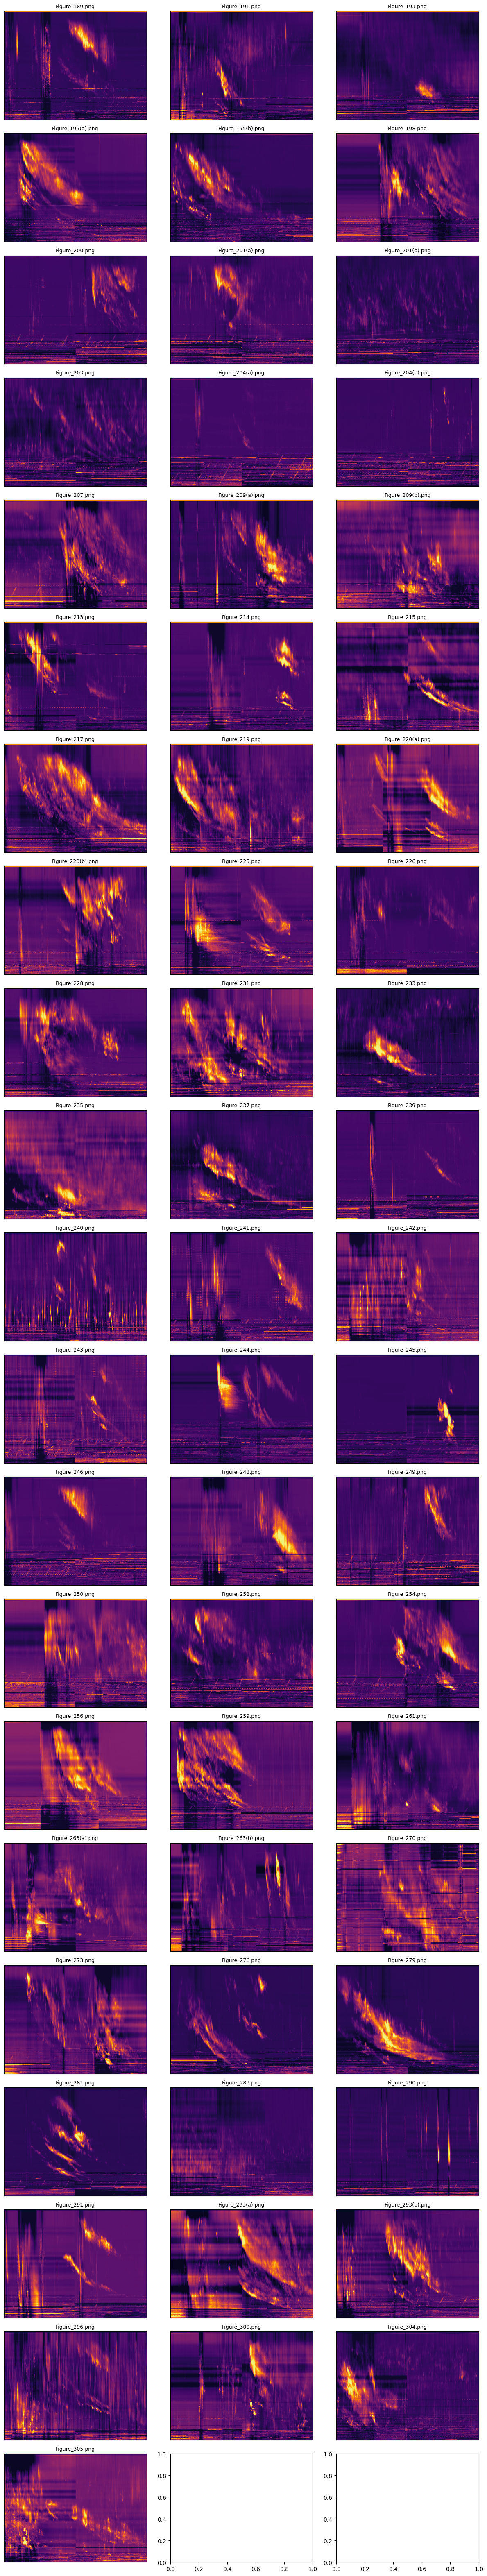

Appended 61 rows → labelled_dataset_7classes_filtered.h5. Backup saved as labelled_dataset_7classes_filtered.h5.old.
New shapes:
  data         -> (6555, 800, 500), dtype=float32
  labels       -> (6555,), dtype=|S21
  freq_range   -> (6555, 2), dtype=float64
  time_range   -> (6555, 2), dtype=float64
  timestamps   -> (6555,), dtype=|S34
  indices      -> (6555,), dtype=int64


In [75]:
# Crop PNGs → (800x500) → preview → SAFE APPEND to labelled H5 with labels=b"2" and placeholders
import numpy as np
from pathlib import Path
from PIL import Image
import h5py, math
import matplotlib.pyplot as plt

# =========================
# CONFIG — EDIT THESE
# =========================
PNG_DIR         = "../Spectrogram"
LABELLED_H5     = "../../../project/lofarsw/Data/Dynspec/labelled_dataset_7classes_filtered.h5"

# Conversion & orientation
MODE            = "grayscale"       # "grayscale" or "inferno"
ROTATE_CCW      = False
FLIP_UD         = True
TARGET_H, TARGET_W = 800, 500

# Auto-crop
AUTO_CROP       = False              # detect panel by removing uniform bg
BORDER_SAMPLE   = 12                # px; width sampled at image borders to estimate bg color
BG_TOL          = 24                # 0..255; higher = more aggressive (treats pixels as "not bg" more easily)

# Manual extra cropping (pixels) AFTER auto-crop (positive numbers shave more)
EXTRA_TOP       = 150
EXTRA_BOTTOM    = 50
EXTRA_LEFT      = 100
EXTRA_RIGHT     = 40

# Optional extra fraction to cut from right (e.g., colorbar)
RIGHT_TRIM_FRAC = 0.15              # 0.10 trims 10% of cropped width from right

# Preview & append
NUM_SHOW        = 61
CONFIRM_APPEND  = True             # <-- set True once you’re happy with previews
COPY_CHUNK      = 512               # rows per chunk when copying old data during safe-append
NEW_LABEL_VALUE = b"2"              # file stores labels as bytes (e.g., |S21)

# =========================
# Helpers: PNG → matrix
# =========================
def to_grayscale_matrix(img: Image.Image, H=800, W=500):
    g = img.convert("L").resize((W, H), resample=Image.BICUBIC)
    return np.asarray(g, dtype=np.float32) / 255.0

def inferno_demapper(img: Image.Image, H=800, W=500):
    """Approx inverse of matplotlib 'inferno' (fallback to grayscale if mpl missing)."""
    try:
        from matplotlib import cm
    except Exception:
        return to_grayscale_matrix(img, H, W)
    lut = (cm.get_cmap("inferno")(np.linspace(0, 1, 256))[:, :3] * 255).astype(np.uint8)
    rgb = img.convert("RGB").resize((W, H), resample=Image.BICUBIC)
    arr = np.asarray(rgb, dtype=np.uint8)
    h, w, _ = arr.shape
    pix = arr.reshape(-1, 3).astype(np.int16)
    diffs = pix[:, None, :] - lut[None, :, :].astype(np.int16)
    d2 = np.sum(diffs * diffs, axis=2)
    idx = np.argmin(d2, axis=1).astype(np.float32)
    return (idx / 255.0).reshape(h, w).astype(np.float32)

# =========================
# Auto-crop: remove background, axes, colorbar
# =========================
def estimate_background_rgb(arr_uint8, border=BORDER_SAMPLE):
    h, w, c = arr_uint8.shape
    frame = np.concatenate([
        arr_uint8[:border, :, :].reshape(-1, c),
        arr_uint8[-border:, :, :].reshape(-1, c),
        arr_uint8[:, :border, :].reshape(-1, c),
        arr_uint8[:, -border:, :].reshape(-1, c),
    ], axis=0)
    return np.median(frame, axis=0)

def find_content_bbox(arr_uint8, bg_rgb, tol=BG_TOL):
    diff = np.abs(arr_uint8.astype(np.int16) - bg_rgb.reshape(1,1,3))
    dist = np.max(diff, axis=2)           # Chebyshev distance
    mask = dist > tol
    if not mask.any():
        h, w = arr_uint8.shape[:2]
        return (0, h, 0, w)
    ys, xs = np.where(mask)
    return int(ys.min()), int(ys.max())+1, int(xs.min()), int(xs.max())+1

def apply_manual_margins(y0, y1, x0, x1, H_img, W_img,
                         extra_top=0, extra_bottom=0, extra_left=0, extra_right=0,
                         right_trim_frac=0.0):
    # optional right trim by fraction first (e.g., colorbar)
    if right_trim_frac > 0:
        width = x1 - x0
        x1 = x0 + max(1, int(width * (1.0 - right_trim_frac)))
    # then pixel margins
    y0 = max(0, y0 + extra_top)
    y1 = min(H_img, y1 - extra_bottom)
    x0 = max(0, x0 + extra_left)
    x1 = min(W_img, x1 - extra_right)
    # keep non-empty
    if y1 <= y0: y1 = min(H_img, y0 + 4)
    if x1 <= x0: x1 = min(W_img, x0 + 4)
    return y0, y1, x0, x1

def crop_dynamic(img: Image.Image):
    if ROTATE_CCW: img = img.rotate(90, expand=True)
    if FLIP_UD:    img = img.transpose(Image.FLIP_TOP_BOTTOM)
    arr = np.asarray(img.convert("RGB"), dtype=np.uint8)
    H_img, W_img = arr.shape[:2]
    if AUTO_CROP:
        bg = estimate_background_rgb(arr, border=BORDER_SAMPLE)
        y0, y1, x0, x1 = find_content_bbox(arr, bg, tol=BG_TOL)
    else:
        y0, y1, x0, x1 = 0, H_img, 0, W_img
    y0, y1, x0, x1 = apply_manual_margins(
        y0, y1, x0, x1, H_img, W_img,
        EXTRA_TOP, EXTRA_BOTTOM, EXTRA_LEFT, EXTRA_RIGHT,
        RIGHT_TRIM_FRAC
    )
    cropped = arr[y0:y1, x0:x1, :]
    return Image.fromarray(cropped)

# =========================
# Convert & preview
# =========================
pngs = sorted(Path(PNG_DIR).glob("*.png"))
if not pngs:
    raise FileNotFoundError(f"No PNGs found in {PNG_DIR}")

mats, names = [], []
for p in pngs:
    imc = crop_dynamic(Image.open(p))
    if MODE == "grayscale":
        mat = to_grayscale_matrix(imc, TARGET_H, TARGET_W)
    elif MODE == "inferno":
        mat = inferno_demapper(imc, TARGET_H, TARGET_W)
    else:
        raise ValueError("MODE must be 'grayscale' or 'inferno'")
    mats.append(mat); names.append(p.name)

X = np.stack(mats).astype(np.float32)  # (K,800,500)
print(f"Cropped & converted {len(names)} PNGs → {X.shape}")

# preview a few
n_show = min(NUM_SHOW, X.shape[0])
cols = min(3, n_show)
rows = int(np.ceil(n_show/cols))
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows), squeeze=False)
for i in range(n_show):
    r, c = divmod(i, cols)
    ax = axes[r][c]
    ax.imshow(X[i], aspect="auto", origin="lower", cmap="inferno")
    ax.set_title(names[i], fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

# =========================
# SAFE APPEND (rebuild to temp then swap)
# =========================
def _create_like(dst, name, src_dset, shape):
    d = dst.create_dataset(
        name, shape=shape, dtype=src_dset.dtype,
        chunks=src_dset.chunks, compression=src_dset.compression,
        shuffle=getattr(src_dset, "shuffle", None),
        fletcher32=getattr(src_dset, "fletcher32", None),
    )
    for k, v in src_dset.attrs.items():
        d.attrs[k] = v
    return d

def _copy_attrs(src, dst):
    for k, v in src.attrs.items():
        dst.attrs[k] = v

def safe_append_labelled(h5_path, new_data, label_value=b"2"):
    K, H, W = new_data.shape
    src_path = Path(h5_path)
    tmp_path = src_path.with_suffix(".tmp.h5")

    with h5py.File(src_path, "r") as src, h5py.File(tmp_path, "w") as dst:
        _copy_attrs(src, dst)
        assert "data" in src, "Expected 'data' dataset in labelled H5."
        data_src = src["data"]
        M = data_src.shape[0]
        assert data_src.shape[1:] == (H, W), f"Existing data {data_src.shape[1:]} != {(H,W)}"

        # data
        data_dst = dst.create_dataset(
            "data", shape=(M+K, H, W), dtype=data_src.dtype,
            chunks=data_src.chunks, compression=data_src.compression,
            shuffle=getattr(data_src, "shuffle", None),
            fletcher32=getattr(data_src, "fletcher32", None),
        )
        for k, v in data_src.attrs.items(): data_dst.attrs[k] = v
        for s in range(0, M, COPY_CHUNK):
            e = min(s + COPY_CHUNK, M)
            data_dst[s:e] = data_src[s:e]
        data_dst[M:M+K] = new_data

        # labels (bytes dtype like |S21)
        if "labels" in src:
            lab_src = src["labels"]
            lab_dst = _create_like(dst, "labels", lab_src, (M+K,))
            lab_dst[:M] = lab_src[:]
            lab_dst[M:] = np.array([label_value]*K, dtype=lab_src.dtype)
        else:
            dt = h5py.string_dtype(encoding="utf-8")
            lab_dst = dst.create_dataset("labels", shape=(M+K,), dtype=dt, chunks=True)
            lab_dst[:M] = np.array([b""]*M, dtype=dt)
            lab_dst[M:] = np.array([label_value]*K, dtype=dt)

        # freq_range & time_range → NaN rows if present
        if "freq_range" in src:
            fr_src = src["freq_range"]
            fr_dst = _create_like(dst, "freq_range", fr_src, (M+K, 2))
            fr_dst[:M] = fr_src[:]
            fr_dst[M:] = np.nan
        if "time_range" in src:
            tr_src = src["time_range"]
            tr_dst = _create_like(dst, "time_range", tr_src, (M+K, 2))
            tr_dst[:M] = tr_src[:]
            tr_dst[M:] = np.nan

        # timestamps → empty bytes if present
        if "timestamps" in src:
            ts_src = src["timestamps"]
            ts_dst = _create_like(dst, "timestamps", ts_src, (M+K,))
            ts_dst[:M] = ts_src[:]
            ts_dst[M:] = np.array([b""]*K, dtype=ts_src.dtype)

        # indices → -1 if present
        if "indices" in src:
            ix_src = src["indices"]
            ix_dst = _create_like(dst, "indices", ix_src, (M+K,))
            ix_dst[:M] = ix_src[:]
            ix_dst[M:] = np.full((K,), -1, dtype=ix_src.dtype)

        # copy other non per-sample datasets/groups as-is
        def copy_other(n, o):
            if n in {"data","labels","freq_range","time_range","timestamps","indices"}:
                return
            if isinstance(o, h5py.Group):
                if n not in dst:
                    g = dst.create_group(n)
                    for k, v in o.attrs.items():
                        g.attrs[k] = v
            elif isinstance(o, h5py.Dataset):
                if len(o.shape) >= 1 and o.shape[0] == M:
                    return  # per-sample: already handled
                d = dst.create_dataset(
                    n, shape=o.shape, dtype=o.dtype,
                    chunks=o.chunks, compression=o.compression,
                    shuffle=getattr(o, "shuffle", None),
                    fletcher32=getattr(o, "fletcher32", None),
                )
                d[...] = o[...]
                for k, v in o.attrs.items(): d.attrs[k] = v
        src.visititems(copy_other)

    # atomic-ish swap with backup
    bak = src_path.with_suffix(src_path.suffix + ".old")
    if bak.exists(): bak.unlink()
    src_path.rename(bak)
    tmp_path.rename(src_path)
    print(f"Appended {K} rows → {src_path.name}. Backup saved as {bak.name}.")

# =========================
# Append if confirmed
# =========================
if CONFIRM_APPEND:
    safe_append_labelled(LABELLED_H5, X, label_value=NEW_LABEL_VALUE)
    with h5py.File(LABELLED_H5, "r") as h5:
        print("New shapes:")
        for k in ("data","labels","freq_range","time_range","timestamps","indices"):
            if k in h5:
                print(f"  {k:12s} -> {h5[k].shape}, dtype={h5[k].dtype}")
else:
    print("Append skipped (CONFIRM_APPEND=False). Set True after verifying crops.")
